In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import skorch
import torch
from skorch import NeuralNetClassifier
from tqdm import tqdm
from torchvision import transforms
import torch.nn as nn
from scipy.stats import entropy
import random
import h5py
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import FeatureAgglomeration

In [2]:


# Compare Algorithmsa
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.semi_supervised import LabelPropagation
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [3]:
from sklearn.metrics import plot_confusion_matrix, matthews_corrcoef, classification_report,confusion_matrix, accuracy_score, balanced_accuracy_score, cohen_kappa_score, f1_score,  precision_score, recall_score
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay


def classification_complete_report(y_true, y_pred ,labels = None  ): 
    print(classification_report(y_true, y_pred, labels = labels))
    print(15*"----")
    print("matthews correlation coeff: %.4f" % (matthews_corrcoef(y_true, y_pred)) )
    print("Cohen Kappa score: %.4f" % (cohen_kappa_score(y_true, y_pred)) )
    print("Accuracy: %.4f & balanced Accuracy: %.4f" % (accuracy_score(y_true, y_pred), balanced_accuracy_score(y_true, y_pred)) )
    print("macro F1 score: %.4f & micro F1 score: %.4f" % (f1_score(y_true, y_pred, average = "macro"), f1_score(y_true, y_pred, average = "micro")) )
    print("macro Precision score: %.4f & micro Precision score: %.4f" % (precision_score(y_true, y_pred, average = "macro"), precision_score(y_true, y_pred, average = "micro")) )
    print("macro Recall score: %.4f & micro Recall score: %.4f" % (recall_score(y_true, y_pred, average = "macro"), recall_score(y_true, y_pred, average = "micro")) )
    cm = confusion_matrix(y_true, y_pred,labels= labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()
    print(15*"----")

In [4]:
metadata = pd.read_csv("/pstore/data/DS4/synapse_data_features/metadata_subset.csv.gz")
metadata

/pstore/apps/Python/3.8.3-2020.07/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3071: DtypeWarning: Columns (6) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,file,experiment,donor,condition,object_number,set,label
0,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_1,Donor_1,+SEA,5156,unlabeled,-1
1,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_1,Donor_1,+SEA,32020,unlabeled,-1
2,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_1,Donor_1,+SEA,55974,unlabeled,-1
3,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_1,Donor_1,+SEA,15150,unlabeled,-1
4,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_1,Donor_1,+SEA,44814,unlabeled,-1
...,...,...,...,...,...,...,...
1065962,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_4,Donor_9,DIG-TCB,72493,unlabeled,-1
1065963,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_4,Donor_9,DIG-TCB,106656,unlabeled,-1
1065964,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_4,Donor_9,DIG-TCB,110990,unlabeled,-1
1065965,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_4,Donor_9,DIG-TCB,71451,unlabeled,-1


In [5]:
set_of_interesting_classes = ['B_cell',  'T_cell', 
                        'T_cell_with_signaling',
                        'T_cell_with_B_cell_fragments',
                        'B_T_cell_in_one_layer',
                        'Synapses_without_signaling', 
                        'Synapses_with_signaling',
                        'No_cell_cell_interaction', 
                        'Multiplets']

In [8]:


label_map = dict()
for i, cl in enumerate(set_of_interesting_classes):
    label_map[cl] = i
label_map['-1'] = -1
label_map[-1] = -1

inv_map = {v: k for k, v in label_map.items()}

In [9]:
inv_map


{0: 'B_cell',
 1: 'T_cell',
 2: 'T_cell_with_signaling',
 3: 'T_cell_with_B_cell_fragments',
 4: 'B_T_cell_in_one_layer',
 5: 'Synapses_without_signaling',
 6: 'Synapses_with_signaling',
 7: 'No_cell_cell_interaction',
 8: 'Multiplets',
 -1: -1}

In [10]:
labeled_index = metadata["label"].isin(set_of_interesting_classes)

train_index = metadata["set"] == "train"
train_index = train_index[train_index].index

validation_index = metadata["set"] == "validation"
validation_index = validation_index[validation_index].index

test_index = metadata["set"] == "test"
test_index = test_index[test_index].index

In [11]:
df_predictions = pd.DataFrame()
df_predictions["label"] = metadata.loc[test_index,"label"]

deepflow_preds = pd.read_csv("ml_and_dl_models/deepflow/deepflow_preds.csv").loc[:,"0"].tolist()
deepflow_preds = [inv_map[x] for x in deepflow_preds]
df_predictions["deepflow_preds"] = deepflow_preds

resnet18_preds = pd.read_csv("ml_and_dl_models/resnet18 with imagenet pretrained/resnet18_preds.csv").loc[:,"0"].tolist()
resnet18_preds = [inv_map[x] for x in resnet18_preds]
df_predictions["resnet18_preds"] = resnet18_preds

resnet34_preds = pd.read_csv("ml_and_dl_models/resnet34 with imagenet pretrained/resnet34_preds.csv").loc[:,"0"].tolist()
resnet34_preds = [inv_map[x] for x in resnet34_preds]
df_predictions["resnet34_preds"] = resnet34_preds

ae_preds = pd.read_csv("ml_and_dl_models/autoencoder features with LR/ae_preds.csv").loc[:,"0"].tolist()
ae_preds = [inv_map[x] for x in ae_preds]
df_predictions["ae_preds"] = ae_preds


LR_preds = pd.read_csv("ml_and_dl_models/interpretable features with LR/LR_preds.csv").loc[:,"0"].tolist()
df_predictions["LR_preds"] = LR_preds

XGBoost_preds = pd.read_csv("ml_and_dl_models/interpretable features with XGBoost/XGBoost_preds.csv").loc[:,"0"].tolist()
df_predictions["XGBoost_preds"] = XGBoost_preds

In [12]:
df_predictions = df_predictions.reset_index(drop = True)

In [13]:
from sklearn.model_selection import RepeatedStratifiedKFold

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10)

predictor_results = pd.DataFrame(columns=["Model", "Macro f1-score", "Accuracy"])

for _, fold_test_index in rskf.split(df_predictions.index, df_predictions.label):
    
    predictor_results = predictor_results.append({
        "Model" : "deepflow", 
        "Macro f1-score": f1_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"deepflow_preds"], average="macro"  ), 
        "Accuracy": accuracy_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"deepflow_preds"])
    }, ignore_index = True)
    
    predictor_results = predictor_results.append({
        "Model" : "resnet18", 
        "Macro f1-score": f1_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"resnet18_preds"], average="macro"  ), 
        "Accuracy": accuracy_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"resnet18_preds"])
    }, ignore_index = True)
    
    predictor_results = predictor_results.append({
        "Model" : "resnet34", 
        "Macro f1-score": f1_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"resnet34_preds"], average="macro"  ), 
        "Accuracy": accuracy_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"resnet34_preds"])
    }, ignore_index = True)
    
    predictor_results = predictor_results.append({
        "Model" : "ae", 
        "Macro f1-score": f1_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"ae_preds"], average="macro"  ), 
        "Accuracy": accuracy_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"ae_preds"])
    }, ignore_index = True)
    
    predictor_results = predictor_results.append({
        "Model" : "lr", 
        "Macro f1-score": f1_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"LR_preds"], average="macro"  ), 
        "Accuracy": accuracy_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"LR_preds"])
    }, ignore_index = True)
    
    predictor_results = predictor_results.append({
        "Model" : "xgb", 
        "Macro f1-score": f1_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"XGBoost_preds"], average="macro"  ), 
        "Accuracy": accuracy_score(df_predictions.loc[fold_test_index,"label"],
                                   df_predictions.loc[fold_test_index,"XGBoost_preds"])
    }, ignore_index = True)


In [14]:
predictor_results

,Model,Macro f1-score,Accuracy
0,deepflow,0.899712,0.901274
1,resnet18,0.899823,0.901274
2,resnet34,0.912723,0.914013
3,ae,0.776313,0.783439
4,lr,0.909097,0.910828
...,...,...,...
295,resnet18,0.898954,0.900958
296,resnet34,0.914281,0.916933
297,ae,0.777363,0.785942
298,lr,0.887714,0.891374


In [22]:
predictor_results.groupby(["Model"]).mean().sort_values("Macro f1-score",  ascending=False).index

Index(['xgb', 'resnet34', 'deepflow', 'resnet18', 'lr', 'ae'], dtype='object', name='Model')

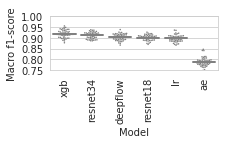

In [19]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize = (3,1)) 

key_order = ['xgb', 'resnet34', 'deepflow', 'resnet18', 'lr', 'ae']

ax = sns.swarmplot(data=predictor_results,x = "Model", 
            y = "Macro f1-score", 
            palette=["Grey"],
                   s = 1.52,
            order = key_order, 
                   ax = ax)

ax = sns.boxplot(
    showmeans=True,
            meanline=True,
            meanprops={'color': 'grey', 'ls': '-', 'lw': 2},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            zorder=10,
            x="Model",
            y="Macro f1-score", 
            order = key_order,
            data=predictor_results,
            showfliers=False,
            showbox=False,
            showcaps=False,
            ax=ax)

ax.set_xticklabels(key_order, rotation = 90)

plt.ylim(0.75, 
         1.00)

plt.yticks([0.75,0.80,0.85,0.90,0.95,1.00])

plt.savefig("Figure - Comparison of different classifers.svg")
plt.savefig("Figure - Comparison of different classifers.png")

In [20]:
for k in key_order:
    indx = predictor_results.Model == k
    print(k, 
          "mean", round(predictor_results.loc[indx, "Macro f1-score"].mean(),2),
         "std", round(predictor_results.loc[indx, "Macro f1-score"].std(),2)           )

xgb mean 0.92 std 0.02
resnet34 mean 0.91 std 0.01
deepflow mean 0.9 std 0.02
resnet18 mean 0.9 std 0.01
lr mean 0.9 std 0.02
ae mean 0.79 std 0.02
